# Finance Data Analysis

**Author:** Ayisha Mariyam  
**Project Type:** Stock Market Data Analysis  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  

-----

# 1. Project Overview

Financial markets generate large volumes of data daily. Analyzing stock data helps identify trends, evaluate risk, and support investment decision-making.

This project performs an exploratory data analysis (EDA) of stock market data to understand price behavior, trading patterns, and relationships between financial indicators.

The main objectives of this project are:

- Load and inspect the stock dataset
- Perform data cleaning and preprocessing
- Analyze stock price distributions
- Identify trends and volatility
- Perform correlation analysis between variables
- Generate insights useful for financial decision-making

This notebook demonstrates practical financial data analysis techniques commonly used in analytics and quantitative research teams.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (9,5)

print("Libraries loaded successfully")

Libraries loaded successfully


#  Dataset Loading

The first step is loading the dataset using the Pandas library.  
This allows us to inspect the data and understand its structure.

In [2]:
# Load dataset

df = pd.read_csv(r"E:\VS CODE\The Developer's Arena Internship 6 months\Month 2\Datasets\finance_stock.csv")

# Display first rows
df.head()

,Stock,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
0,AAPL,2010-01-04,445.627510,465.464143,431.513035,450.378213,2441288,301.310351,64.061774,2.449751,464.398638,438.231589,2.845199,1.505217,4.360374,-0.079418,445.714557,0
1,AAPL,2010-01-05,441.194244,449.726464,432.618124,437.397748,4714199,280.015623,52.032235,-3.726473,450.099041,431.018080,3.352677,1.516110,2.309996,0.511900,439.507357,1
2,AAPL,2010-01-07,395.417421,399.413060,385.055059,388.718345,3948217,323.131496,71.817441,-4.215862,396.010670,374.092744,3.471209,2.256823,0.984588,0.049279,387.335810,0
3,AAPL,2010-01-11,478.631057,501.639769,461.991967,484.401144,3637733,273.944016,67.133451,1.574418,496.399599,479.317188,2.962110,2.238436,1.754234,0.737874,476.642532,0
4,AAPL,2010-01-12,179.950904,183.900759,175.076588,181.516782,693492,237.354447,84.797294,1.552505,189.479672,171.610610,2.727858,2.378014,2.562107,-0.905092,182.863272,1


#  Dataset Overview

Before performing analysis, it is important to understand:

- Dataset dimensions
- Column names
- Data types
- Basic statistics

In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50349 entries, 0 to 50348
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Stock            50349 non-null  str    
 1   Date             50349 non-null  str    
 2   Open             50349 non-null  float64
 3   High             50349 non-null  float64
 4   Low              50349 non-null  float64
 5   Close            50349 non-null  float64
 6   Volume           50349 non-null  int64  
 7   SMA_10           50349 non-null  float64
 8   RSI              50349 non-null  float64
 9   MACD             50349 non-null  float64
 10  Bollinger_Upper  50349 non-null  float64
 11  Bollinger_Lower  50349 non-null  float64
 12  GDP_Growth       50349 non-null  float64
 13  Inflation_Rate   50349 non-null  float64
 14  Interest_Rate    50349 non-null  float64
 15  Sentiment_Score  50349 non-null  float64
 16  Next_Close       50349 non-null  float64
 17  Target           50349 

In [4]:
# Summary statistics

df.describe()

,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
count,50349.000000,50349.000000,50349.000000,50349.000000,5.034900e+04,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000,50349.000000
mean,274.949818,281.765893,268.061694,274.924734,2.547134e+06,274.910267,49.827072,0.007013,284.924427,264.916157,3.000355,2.250040,2.746320,0.001429,274.943789,0.501976
std,129.861782,133.040144,126.627094,129.786177,1.413136e+06,40.732721,23.097843,2.887802,129.831090,129.825109,0.289456,0.433514,1.297482,0.577099,129.855561,0.500001
min,49.106664,50.227411,47.755292,50.078817,1.000890e+05,91.000865,10.000911,-4.999912,55.160167,35.759134,2.500040,1.500009,0.500014,-0.999921,49.443977,0.000000
25%,162.088317,166.265621,158.015601,162.105889,1.321219e+06,247.286597,29.847647,-2.511063,172.264659,152.149801,2.750128,1.871944,1.626444,-0.499875,162.272760,0.000000
50%,274.928366,281.961442,268.121257,275.005601,2.546261e+06,274.911668,49.906363,0.011629,285.012100,264.655584,2.999740,2.251659,2.746131,0.004065,275.056340,1.000000
75%,386.653578,396.218846,376.748125,386.636207,3.767910e+06,302.526785,69.821850,2.516192,396.673124,376.636601,3.250861,2.624896,3.862460,0.499449,386.790854,1.000000
max,509.361090,524.861970,499.339660,499.962629,4.999977e+06,438.897688,89.999704,4.999610,514.789524,494.472084,3.499968,2.999991,4.999880,0.999966,509.341161,1.000000


#  Data Quality Assessment

Data quality issues such as missing values or duplicate records may affect analysis accuracy.

Therefore, we check the dataset for:

- Missing values
- Duplicate rows

In [5]:
# Check missing values

df.isnull().sum()

Stock              0
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_10             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
GDP_Growth         0
Inflation_Rate     0
Interest_Rate      0
Sentiment_Score    0
Next_Close         0
Target             0
dtype: int64

In [6]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [10]:
# Verify dataset shape
df.shape

(50349, 18)

#  Data Cleaning

To ensure reliable analysis:

- Missing values will be removed
- Duplicate rows will be dropped
- Data types will be verified

In [8]:
# No missing & duplicate values in this dataset

# Correcting Data types

df['Date'] = pd.to_datetime(df['Date'])

df.dtypes

Stock                         str
Date               datetime64[us]
Open                      float64
High                      float64
Low                       float64
Close                     float64
Volume                      int64
SMA_10                    float64
RSI                       float64
MACD                      float64
Bollinger_Upper           float64
Bollinger_Lower           float64
GDP_Growth                float64
Inflation_Rate            float64
Interest_Rate             float64
Sentiment_Score           float64
Next_Close                float64
Target                      int64
dtype: object

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns and trends in stock price data.

The following analyses will be conducted:

1. Distribution of stock prices
2. Volume trading analysis
3. Price trend visualization
4. Relationship between price indicators
5. Correlation analysis

##  Stock Price Distribution

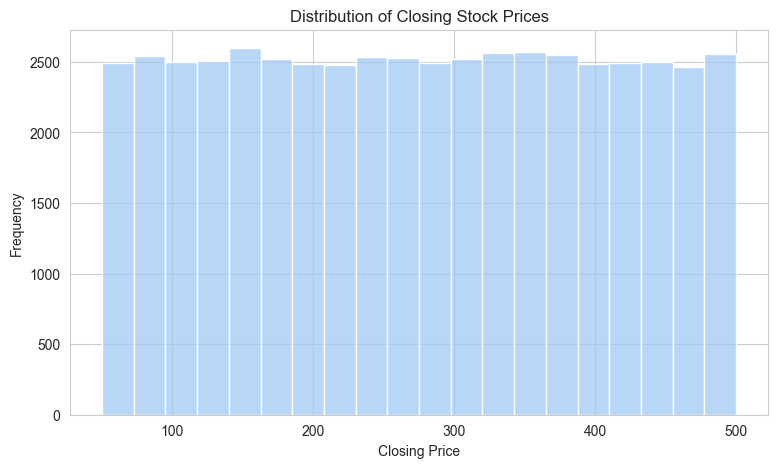

In [11]:
sns.histplot(df['Close'], bins=20)

plt.title("Distribution of Closing Stock Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

##  Trading Volume Distribution

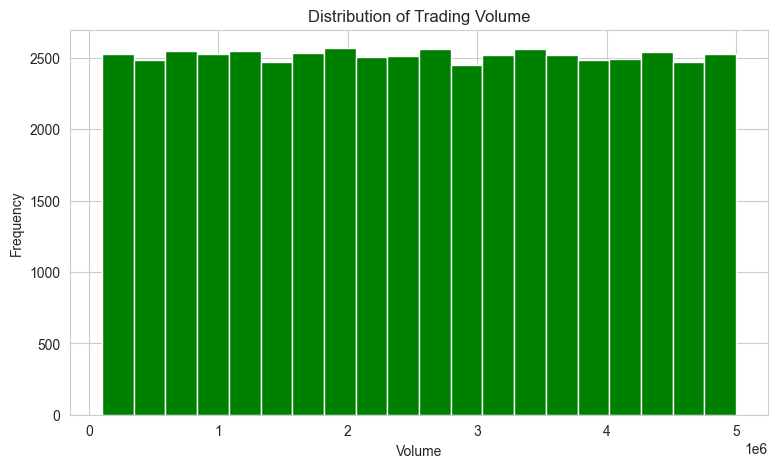

In [13]:
plt.hist(df['Volume'], bins=20, color='green')

plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

## Stock Price Trend

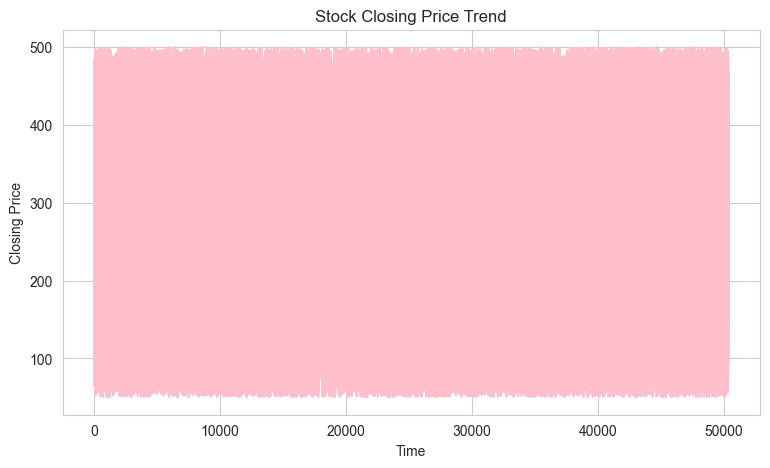

In [16]:
plt.plot(df['Close'], color='pink')

plt.title("Stock Closing Price Trend")
plt.xlabel("Time")
plt.ylabel("Closing Price")

plt.show()

# Price Relationships

## Open vs Close Prices

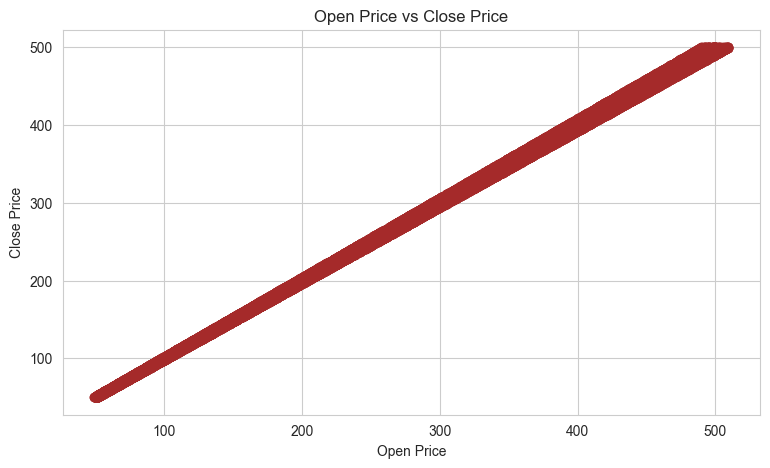

In [20]:
plt.scatter(df['Open'], df['Close'], color='brown')

plt.title("Open Price vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")

plt.show()

## High vs Low Prices

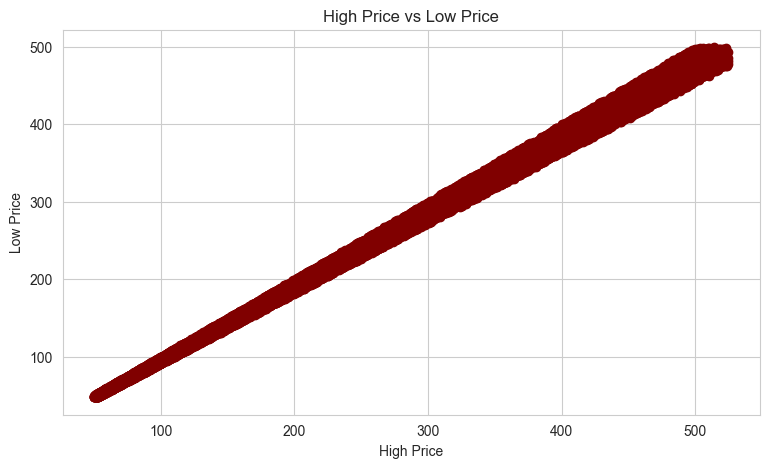

In [21]:
plt.scatter(df['High'], df['Low'], color='maroon')

plt.title("High Price vs Low Price")
plt.xlabel("High Price")
plt.ylabel("Low Price")

plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships between stock price indicators.

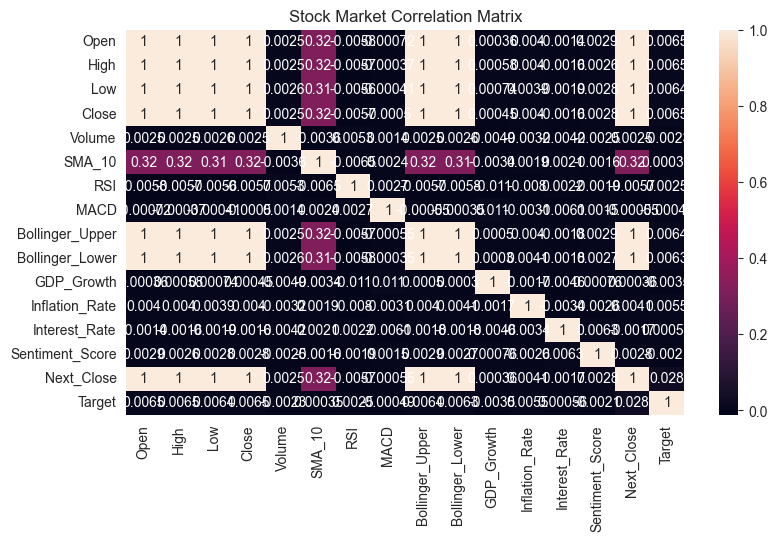

In [23]:
correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True)

plt.title("Stock Market Correlation Matrix")

plt.show()

#  Volatility Analysis

Stock volatility measures how much stock prices fluctuate over time.

Higher volatility generally indicates higher risk for investors.

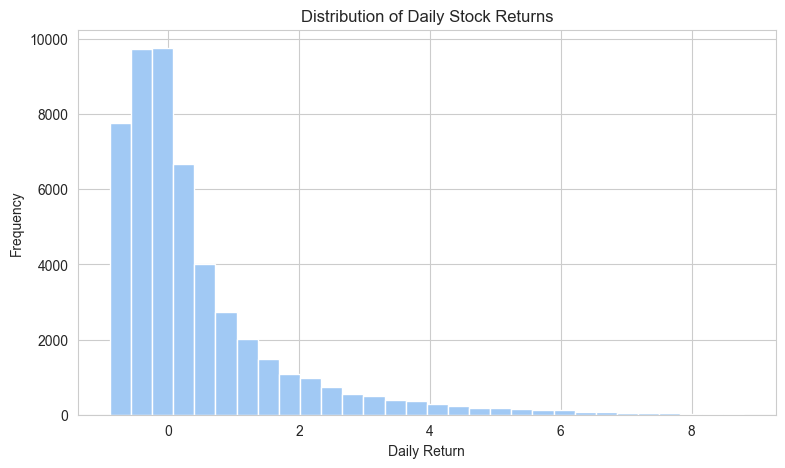

In [24]:
# Calculate daily returns

df['Daily_Return'] = df['Close'].pct_change()

# Plot returns distribution

plt.hist(df['Daily_Return'].dropna(), bins=30)

plt.title("Distribution of Daily Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

#  Key Insights

The analysis of the stock dataset provides several important insights:

- Stock closing prices show fluctuations over time, reflecting market volatility.
- Trading volume varies significantly across trading periods.
- A strong relationship exists between opening and closing prices.
- High and low prices are closely correlated as they represent daily price ranges.
- Daily return analysis highlights the variability in stock performance.

These findings provide useful insights into stock behavior and market dynamics.

#  Statistical Insights

Key statistical observations include:

- Closing price values show a wide range indicating varying stock performance.
- Daily return distribution suggests moderate volatility.
- Strong correlations exist between price-related variables (Open, Close, High, Low).
- Trading volume demonstrates large fluctuations indicating variable market activity.

These statistical insights help evaluate stock performance and market risk.

#  Business Insights and Recommendations

Based on the analysis, the following financial insights can be derived:

1. Investors should monitor periods of high volatility to manage risk effectively.
2. Strong correlations between price indicators suggest predictable market patterns.
3. Trading volume spikes may indicate increased market interest or major events.
4. Risk management strategies should consider daily return volatility.

Financial analytics can significantly improve investment decision-making and portfolio management.

#  Conclusion

This project analyzed stock market data using Python and data visualization techniques.

Key steps performed include:

- Data loading and preprocessing
- Exploratory data analysis
- Visualization of stock price trends
- Correlation and volatility analysis

Stock data analytics plays a critical role in financial forecasting, portfolio management, and investment strategy development.

Future improvements may include:

- Time series forecasting using ARIMA or Prophet
- Machine learning models for stock prediction
- Portfolio optimization analysis